<a href="https://colab.research.google.com/github/shanikagalaudage/includeher_paper/blob/main/PlotsTables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes
Note this notebook was originally created for the IncludeHer paper, Invisible women: Gender representation in high school science courses across Australia, Ross et al., 2023 (kathryn.ross@curtin.edu.au) which can be found here: https://journals.sagepub.com/doi/full/10.1177/00049441231197245

The notebook has now been modified by Greg Cooke (gjc53@cam.ac.uk) to investigate similar statistics for UK syllabi for 14-16 year olds (GCSE) and 16-18 year olds (A-Level)

# UK A-Level Analysis

In [138]:
# Imports
import numpy as np
import json

from matplotlib import rcParams
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# Set plot formatting
rcParams["legend.framealpha"]=0.5
rcParams["legend.frameon"]=True
rcParams["legend.edgecolor"]="white"
rcParams["axes.labelsize"]=14
rcParams["axes.grid"] = True
rcParams["grid.color"] = "black"
rcParams["grid.linewidth"] = 1.0
rcParams["grid.linestyle"] = "--"
rcParams["grid.alpha"] = 0.2

rcParams["xtick.labelsize"]=20
rcParams["ytick.labelsize"]=20
rcParams["legend.fontsize"]=22
rcParams["axes.labelsize"]=22
rcParams["axes.titlesize"]=22


colours = ["#3E284F", "#AB7AD1", "#024963", "#3D9CB3","#C7639D", "#FAA7CB", "#FFEDF7", "#663351"]
colours = ["#1c579e", "#1c9e79", "#024963", "#3D9CB3","#C7639D", "#FAA7CB", "#FFEDF7", "#663351"]

# Create JSON files

In [139]:
import json

import json

# Exam boards (these really are global, so keep them explicit)
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish highers", "WJEC"]

EXAMBOARDS = {
    "AQA": "AQA",
    "CCEA": "CCEA",
    "Edexcel": "Edexcel",
    "OCR": "OCR",
    "Scottish highers": "Scottish_highers",
    "WJEC": "WJEC",
}

# Read in the JSON files
dataset = {}
for board in exam_boards:
    path = f"../Stats/{EXAMBOARDS[board]}_SummaryStats_A_Level.json"
    with open(path, "r", encoding="utf-8") as ff:
        dataset[EXAMBOARDS[board]] = json.load(ff)




In [140]:
# ------------------------------------------------------------
# Create a json data file with all statistics (robust version)
# ------------------------------------------------------------
subjects = {"physics", "chemistry", "biology", "environmental science", "geology"}
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR", "Scottish highers", "WJEC"]
categories = ["concept", "scientist"]


def get_counts(board, subject, category):
    """Return (male, female) counts or (0, 0) if missing."""
    subj = dataset[EXAMBOARDS[board]]["subjects"].get(subject)
    if subj is None:
        return 0, 0
    cat = subj.get(category)
    if cat is None:
        return 0, 0
    return cat["male"], cat["female"]


stats_data = {}

# ------------------------------------------------------------
# Per-subject / per-category / per-board statistics
# ------------------------------------------------------------

for sb in subjects:
    stats_data[sb] = {}
    for cat in categories:
        stats_data[sb][cat] = {}
        for eb in exam_boards:
            m, f = get_counts(eb, sb, cat)
            stats_data[sb][cat][eb] = {
                "male": m,
                "female": f,
                "both": m + f
            }

# ------------------------------------------------------------
# OVERALL SECTION
# ------------------------------------------------------------

stats_data["overall"] = {
    "subjects": {},
    "exam_boards": {}
}

tot_across_boards_categories_subjects = 0
tot_across_boards_concept_subjects = 0
tot_across_boards_scientist_subjects = 0

# ------------------------------------------------------------
# Overall by subject
# ------------------------------------------------------------

for sb in subjects:
    stats_data["overall"]["subjects"][sb] = {}
    subject_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for eb in exam_boards
        )
        stats_data["overall"]["subjects"][sb][cat] = cat_total
        subject_total += cat_total

    stats_data["overall"]["subjects"][sb]["total"] = subject_total

    tot_across_boards_concept_subjects += stats_data["overall"]["subjects"][sb].get("concept", 0)
    tot_across_boards_scientist_subjects += stats_data["overall"]["subjects"][sb].get("scientist", 0)
    tot_across_boards_categories_subjects += subject_total


for sb in subjects:
    stats_data["overall"]["subjects"][sb]["% of total mentions"] = round(
        stats_data["overall"]["subjects"][sb]["total"]
        / tot_across_boards_categories_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total concept mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("concept", 0)
        / tot_across_boards_concept_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total scientist mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("scientist", 0)
        / tot_across_boards_scientist_subjects * 100, 2
    )

# ------------------------------------------------------------
# Overall by exam board
# ------------------------------------------------------------

tot_across_subjects_categories_boards = 0
tot_across_subjects_concept_boards = 0
tot_across_subjects_scientist_boards = 0

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb] = {}
    board_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for sb in subjects
        )
        stats_data["overall"]["exam_boards"][eb][cat] = cat_total
        board_total += cat_total

    stats_data["overall"]["exam_boards"][eb]["total"] = board_total

    tot_across_subjects_concept_boards += stats_data["overall"]["exam_boards"][eb].get("concept", 0)
    tot_across_subjects_scientist_boards += stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
    tot_across_subjects_categories_boards += board_total


for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb]["% of total mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["total"]
        / tot_across_subjects_categories_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total concept mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("concept", 0)
        / tot_across_subjects_concept_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total scientist mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
        / tot_across_subjects_scientist_boards * 100, 2
    )

# ------------------------------------------------------------
# Top-level totals
# ------------------------------------------------------------

stats_data["overall"]["total mentions"] = tot_across_boards_categories_subjects
stats_data["overall"]["total concept mentions"] = tot_across_boards_concept_subjects
stats_data["overall"]["total scientist mentions"] = tot_across_boards_scientist_subjects

# ------------------------------------------------------------
# Write out
# ------------------------------------------------------------

with open('../Stats/FullSummaryStatsUK_A_Level.json', 'w', encoding="utf-8") as fp:
    json.dump(stats_data, fp, indent=4)


# UK Education Figures

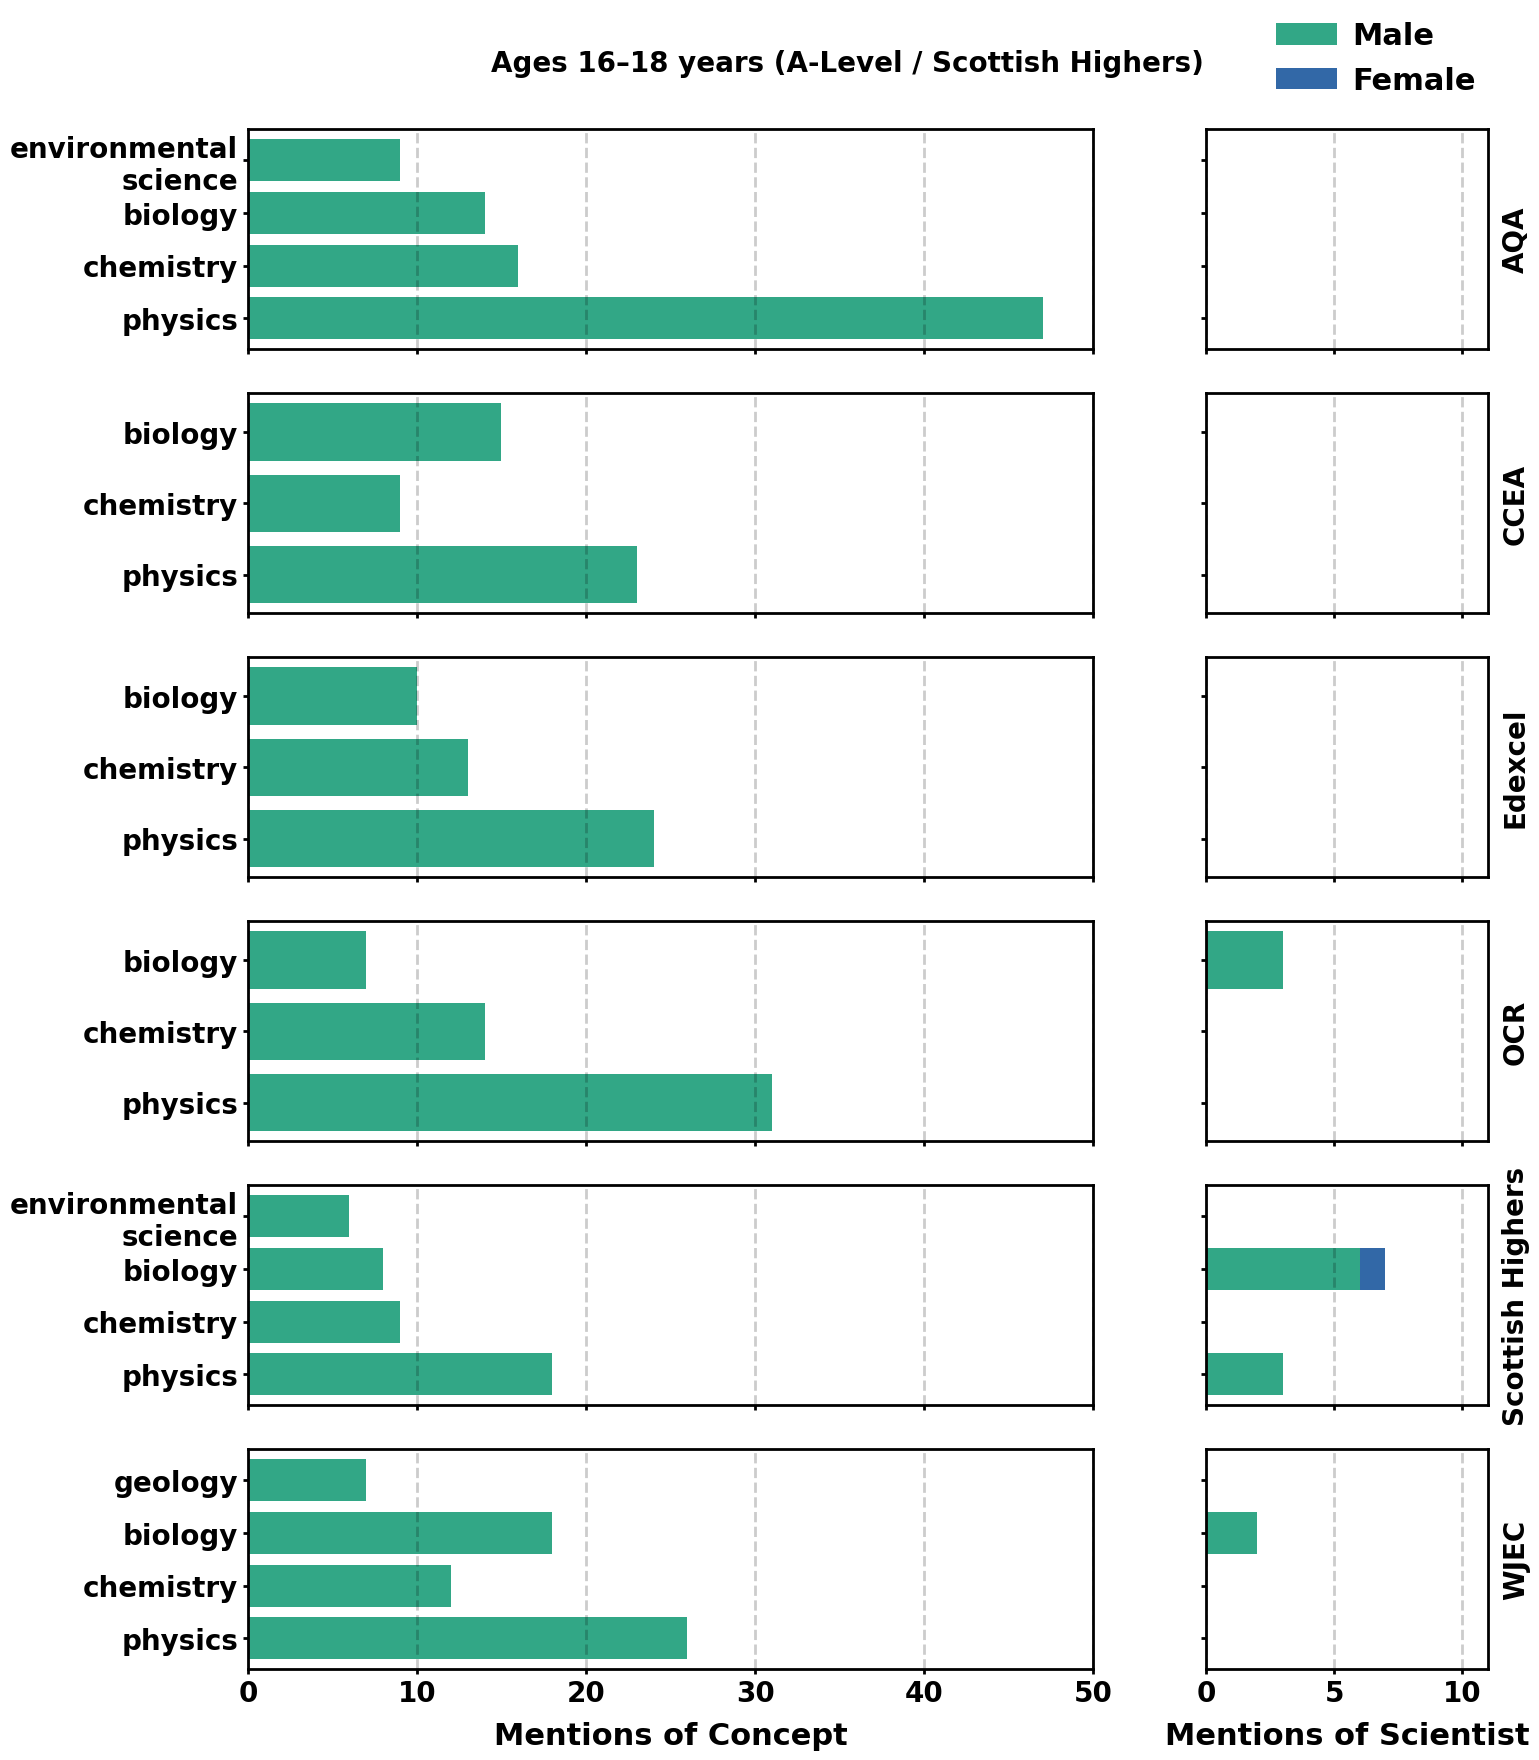

In [141]:
# ------------------------------------------------------------
# Global style: bold text + thicker axes
# ------------------------------------------------------------
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['axes.linewidth'] = 2

# ------------------------------------------------------------
# Create horizontal bar chart for breakdown across subjects
# ------------------------------------------------------------
subject_display_names = {
    "environmental science": "environmental\nscience"
}

core_subjects = {"physics", "chemistry", "biology"}

fig, axs = plt.subplots(
    nrows=len(exam_boards),
    ncols=2,
    figsize=(16, 20),
    gridspec_kw={'width_ratios': [0.75, 0.25]}
)

# ------------------------------------------------------------
# Left column: concepts
# ------------------------------------------------------------

for ii, board in enumerate(exam_boards):

    subjects_here = [
        sb for sb, data in dataset[EXAMBOARDS[board]]["subjects"].items()
        if (
            sb in core_subjects
            or (
                "concept" in data
                and (data["concept"]["male"] + data["concept"]["female"]) > 0
            )
        )
    ]

    y = range(len(subjects_here))

    male = []
    female = []

    for sb in subjects_here:
        cat = dataset[EXAMBOARDS[board]]["subjects"][sb].get("concept")
        if cat is None:
            m, f = 0, 0
        else:
            m, f = cat["male"], cat["female"]
        male.append(m)
        female.append(f)

    axs[ii, 0].barh(y, male, color=colours[1], alpha=0.9)
    axs[ii, 0].barh(y, female, left=male, color=colours[0], alpha=0.9)

    axs[ii, 0].set_yticks(y)
    axs[ii, 0].set_yticklabels(
        [subject_display_names.get(sb, sb) for sb in subjects_here],
        fontweight='bold'
    )

    axs[ii, 1].text(
        1.05,
        0.5,
        'Scottish Highers' if board == 'Scottish highers' else board,
        rotation=90,
        ha='left',
        va='center',
        fontsize=20,
        fontweight='bold',
        transform=axs[ii, 1].transAxes
    )

    axs[ii, 0].set_xlim(0, 50)

    if ii != len(exam_boards) - 1:
        axs[ii, 0].tick_params(labelbottom=False)


# ------------------------------------------------------------
# Right column: scientists
# ------------------------------------------------------------

for ii, board in enumerate(exam_boards):

    subjects_here = [
        sb for sb, data in dataset[EXAMBOARDS[board]]["subjects"].items()
        if (
            sb in core_subjects
            or (
                "concept" in data
                and (data["concept"]["male"] + data["concept"]["female"]) > 0
            )
        )
    ]

    y = range(len(subjects_here))

    male = []
    female = []

    for sb in subjects_here:
        cat = dataset[EXAMBOARDS[board]]["subjects"][sb].get("scientist")
        if cat is None:
            m, f = 0, 0
        else:
            m, f = cat["male"], cat["female"]
        male.append(m)
        female.append(f)

    axs[ii, 1].barh(y, male, color=colours[1], alpha=0.9)
    axs[ii, 1].barh(y, female, left=male, color=colours[0], alpha=0.9)

    axs[ii, 1].set_yticks(y)
    axs[ii, 1].set_yticklabels(subjects_here, fontweight='bold')

    axs[ii, 1].set_xlim(0, 11)
    axs[ii, 1].tick_params(labelleft=False)

    if ii != len(exam_boards) - 1:
        axs[ii, 1].tick_params(labelbottom=False)


# ------------------------------------------------------------
# Axis labels, legend, layout
# ------------------------------------------------------------

axs[-1, 0].set_xlabel("Mentions of Concept", labelpad=10, fontweight='bold')
axs[-1, 1].set_xlabel("Mentions of Scientist", labelpad=10, fontweight='bold')

plt.figlegend(
    ['Male', 'Female'],
    bbox_to_anchor=(0.9, 0.94),
    bbox_transform=fig.transFigure,
    ncol=1,
    borderaxespad=0.,
    handletextpad=0.5,
    columnspacing=1,
    prop={'weight': 'bold'}
)

plt.suptitle(
    'Ages 16–18 years (A-Level / Scottish Highers)',
    fontsize=20,
    fontweight='bold',
    y=0.92
)

# ------------------------------------------------------------
# Make all spines linewidth = 2
# ------------------------------------------------------------
for ax in axs.flat:
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# ------------------------------------------------------------
# Vertical grid only (x-axis), no horizontal grid
# ------------------------------------------------------------
for ax in axs.flat:
    ax.grid(True, axis='x', linewidth=2)
    ax.grid(False, axis='y')

plt.savefig(
    '../Figures/summary_subjects_A_Level_UK.png',
    dpi=100,
    bbox_inches='tight'
)


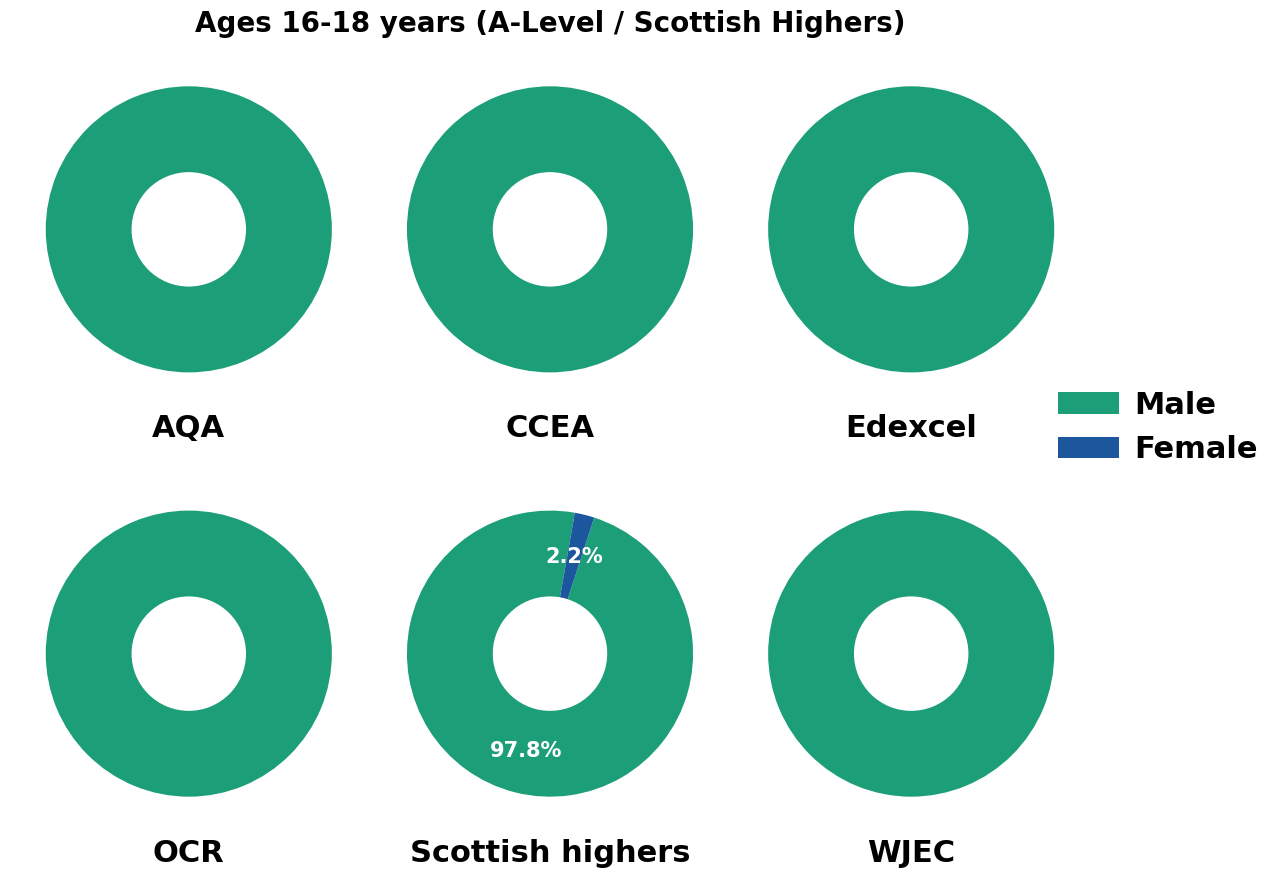

In [142]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # flatten to make indexing easier

for jj in range(6):
    m = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["male"]
    f = dataset[EXAMBOARDS[exam_boards[jj]]]["overall"]["unique"]["female"]
    val = [m, f]
    if f == 0:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
        )
    else:
        ax[jj].pie(
            val, colors=[colours[1], colours[0]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 15, 'color': 'white'}
        )
    
    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Optional: hide any unused axes (e.g. if you ever use fewer than 6)
for kk in range(len(ax)):
    if kk >= len(exam_boards):
        ax[kk].axis('off')
        
plt.figlegend(['Male', 'Female'], bbox_to_anchor=(1.1, 0.57),#(1, 0.55)
              bbox_transform=fig.transFigure, ncol=1, borderaxespad=0.,
              handletextpad=0.5, columnspacing=1)

plt.subplots_adjust(wspace=0.01, hspace=0.1, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('Ages 16-18 years (A-Level / Scottish Highers)', fontsize=20, weight = 'bold')

plt.savefig('../Figures/summary_male_vs_female_UK_A_Level.png', dpi = 100, bbox_inches='tight')


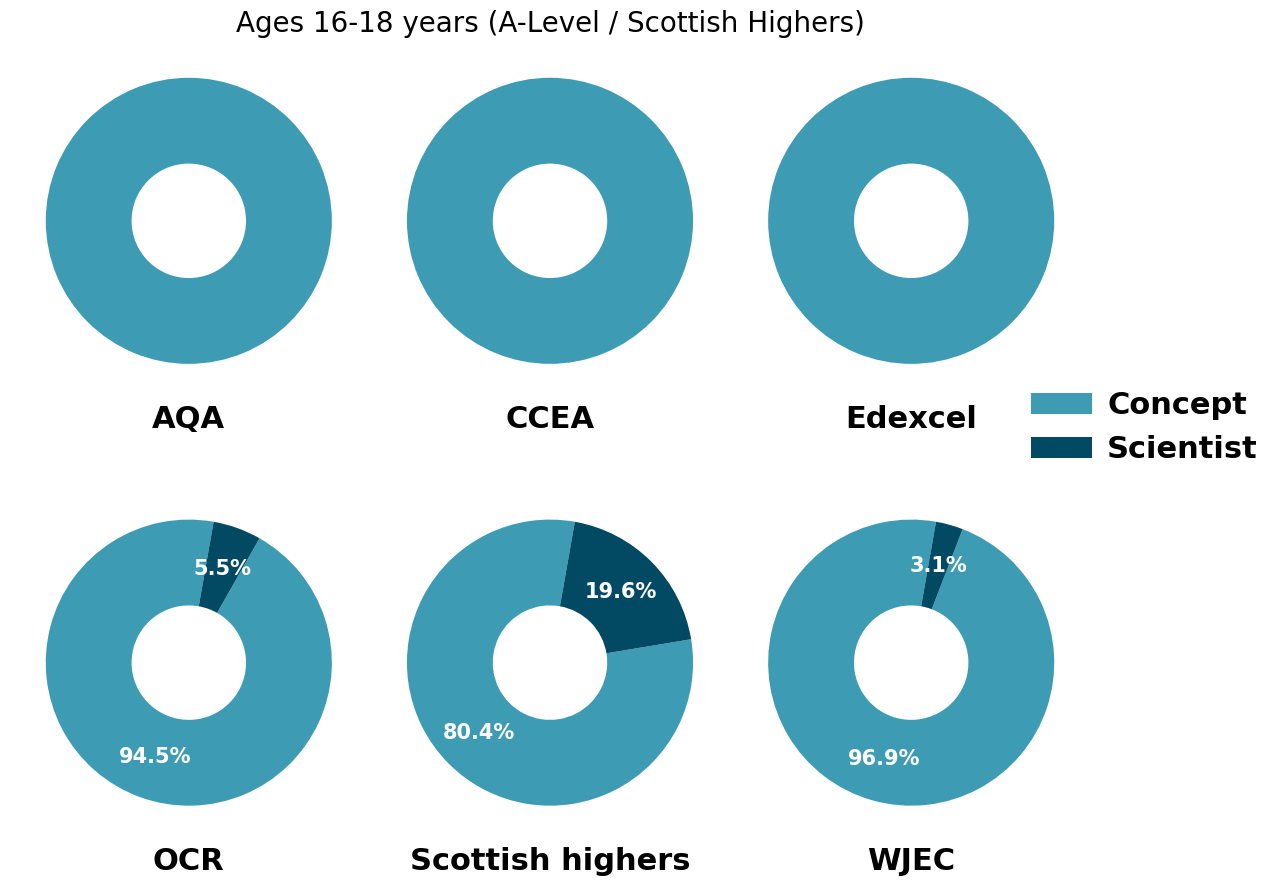

In [143]:
# Create pie charts showing scientist vs concept breakdown per exam board
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
ax = ax.flatten()  # Flatten to simplify iteration

for jj in range(6):  # for each exam board
    board_key = EXAMBOARDS[exam_boards[jj]]
    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]

    val = [m1 + f1, m2 + f2]  # [concepts, scientists]

    if m2 + f2 == 0:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val, colors=[colours[3], colours[2]],
            startangle=80, wedgeprops=dict(width=.6),
            autopct='%1.1f%%', pctdistance=0.7,
            textprops={'fontsize': 15, 'color': 'white'}
        )

    if (exam_boards[jj] == 'Scottish_highers'):
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(exam_boards[jj])

# Add legend
plt.figlegend(['Concept', 'Scientist'], bbox_to_anchor=(1.1, 0.57),
              bbox_transform=fig.transFigure, ncol=1,
              borderaxespad=0., handletextpad=0.5, columnspacing=1)

# Adjust spacing
plt.subplots_adjust(wspace=0.01, hspace=0.2, left=0.05, right=0.95, top=0.95, bottom=0.05)

plt.suptitle('Ages 16-18 years (A-Level / Scottish Highers)', fontsize=20)

plt.savefig('../Figures/summary_concept_vs_scientist_UK_A_Level.png', dpi = 100, bbox_inches='tight')


In [144]:
def collect_region_data(exam_boards, dataset, EXAMBOARDS):
    region_list = []
    nan_regions = set()

    for state in exam_boards:
        region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
        for r in region_keys:
            if isinstance(r, str):
                r_clean = r.strip().title()
                if r_clean == "Eruope":
                    r_clean = "Europe"
                if r_clean.lower() == "nan":
                    nan_regions.add(r)
                else:
                    region_list.append(r_clean)
            else:
                nan_regions.add(r)

    regions = sorted(set(region_list))

    name_list = []
    region = []
    nan_regions_scientist = set()

    for state in exam_boards:
        names = list(dataset[EXAMBOARDS[state]]["names"].keys())
        for name in names:
            r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
            if isinstance(r, str):
                r_clean = r.strip().title()
                if r_clean == "Eruope":
                    r_clean = "Europe"
                if r_clean.lower() == "nan":
                    nan_regions_scientist.add(r)
                else:
                    region.append(r_clean)
                    name_list.append(name)
            else:
                nan_regions_scientist.add(r)

    idx = [name_list.index(x) for x in set(name_list)]
    region_names = [region[i] for i in idx]

    vals = [region_names.count(rr) for rr in regions]
    total = sum(vals)

    def wrap_label(label, max_words=2):
        words = label.split()
        return "\n".join(
            " ".join(words[i:i + max_words])
            for i in range(0, len(words), max_words)
        )

    labels = [
        f"{wrap_label(r)}\n({v/total*100:.1f}%)"
        for r, v in zip(regions, vals)
    ]

    return regions, vals, labels

'''
Save A-level data to be plotted later
'''
regions_A, vals_A, labels_A = collect_region_data(
    exam_boards, dataset, EXAMBOARDS
)

Excluded 'nan' or malformed region entries from 'overall':
  - 'nan'
Excluded 'nan' or malformed region entries from scientists:
  - 'nan'


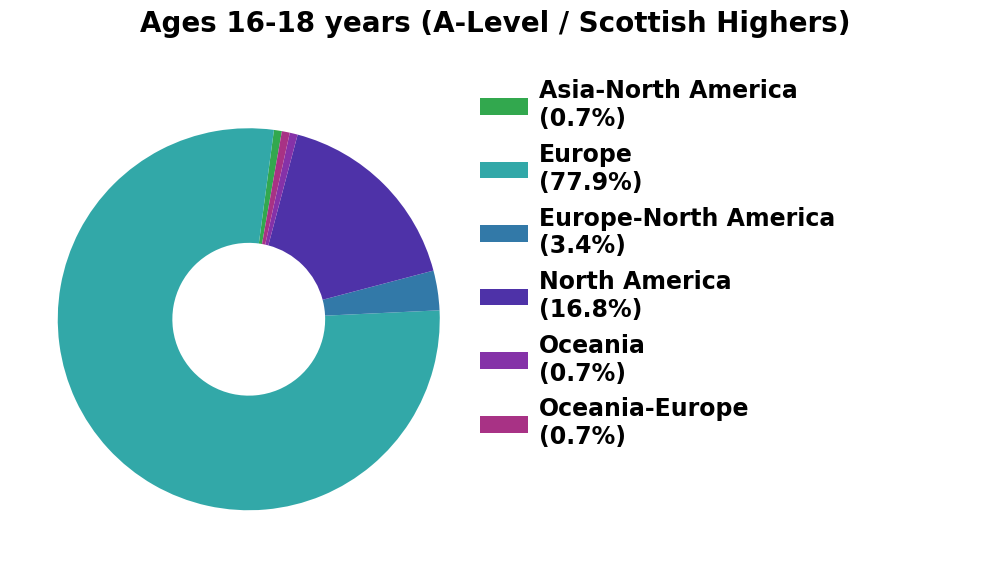

In [145]:
import matplotlib.pyplot as plt
import numpy as np

# --- Collect and clean data ---
region_list = []
nan_regions = set()
for state in exam_boards:
    region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
    for r in region_keys:
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions.add(r)
            else:
                region_list.append(r_clean)
        else:
            nan_regions.add(r)

# Print nan or malformed entries
if nan_regions:
    print("Excluded 'nan' or malformed region entries from 'overall':")
    for r in nan_regions:
        print(f"  - {repr(r)}")

regions = sorted(set(region_list))

# Assign colors using a qualitative palette
cmap = plt.get_cmap('Set3')

Colours = ["#32a84e", "#32a8a8", "#3279a8",
           "#4e32a8", "#8532a8", "#a83285"]



#colours = [cmap(i % cmap.N) for i in range(len(regions))]

# --- Build list of unique scientist names and regions ---
name_list = []
region = []
nan_regions_scientist = set()
for state in exam_boards:
    names = list(dataset[EXAMBOARDS[state]]["names"].keys())
    for name in names:
        r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions_scientist.add(r)
            else:
                region.append(r_clean)
                name_list.append(name)
        else:
            nan_regions_scientist.add(r)

# Print nan or malformed entries
if nan_regions_scientist:
    print("Excluded 'nan' or malformed region entries from scientists:")
    for r in nan_regions_scientist:
        print(f"  - {repr(r)}")

# Remove duplicate scientist names (preserve first mention)
idx = [name_list.index(x) for x in set(name_list)]
unique_names = [name_list[i] for i in idx]
region_names = [region[i] for i in idx]

# Count by region
vals = [region_names.count(rr) for rr in regions]

# Format region names with percentages for the legend
total = sum(vals)
region_labels = [f"{r} ({v/total*100:.1f}%)" for r, v in zip(regions, vals)]

def wrap_label(label, max_words=2):
    words = label.split()
    lines = []
    for i in range(0, len(words), max_words):
        lines.append(" ".join(words[i:i+max_words]))
    return "\n".join(lines)

region_labels = [
    f"{wrap_label(r)}\n({v/total*100:.1f}%)" for r, v in zip(regions, vals)
]


# --- Plotting ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

# Main pie chart (no % inside)
ax[0].pie(
    vals, colors=Colours, startangle=80,
    wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'}
)

# Dummy pie chart for layout spacing
ax[1].pie(vals, colors=['white'] * len(vals))

# Legend with region names and percentages
plt.figlegend(
    region_labels,
    bbox_to_anchor=(0.85, 0.88),
    bbox_transform=fig.transFigure,
    ncol=1, borderaxespad=0., handletextpad=0.5, columnspacing=1,
    fontsize=17
)

plt.suptitle('Ages 16-18 years (A-Level / Scottish Highers)', fontsize=20, weight = 'bold')

plt.tight_layout()

plt.savefig('../Figures/summary_region_all_UK_A_Level.png',
            dpi=100,
            bbox_inches='tight')


# GCSE analysis

#### Code is essentially the same, just with different paths and files

In [146]:
import json

# Exam boards (these really are global, so keep them explicit)
exam_boards = ["AQA", "CCEA", "Edexcel", "OCR A", "OCR B", "Scottish NQ5", "WJEC"]

EXAMBOARDS = {
    "AQA": "AQA_GCSE",
    "CCEA": "CCEA_GCSE",
    "Edexcel": "Edexcel_GCSE",
    "OCR A": "OCR_A_GCSE",
    "OCR B": "OCR_B_GCSE",
    "Scottish NQ5": "Scottish_NQ5",
    "WJEC": "WJEC_GCSE",
}

# Read in the JSON files
dataset = {}
for board in exam_boards:
    path = f"../Stats/{EXAMBOARDS[board]}_SummaryStats_GCSE.json"
    with open(path, "r", encoding="utf-8") as ff:
        dataset[EXAMBOARDS[board]] = json.load(ff)

# ------------------------------------------------------------------
# Derive subjects dynamically (this is the key change)
# ------------------------------------------------------------------

# All subjects that appear in any exam board
subjects = sorted({
    sb
    for board in exam_boards
    for sb in dataset[EXAMBOARDS[board]]["subjects"].keys()
})

# Use this wherever you previously used `labels`
labels = subjects


In [147]:
# ------------------------------------------------------------
# Create a json data file with all statistics (robust version)
# ------------------------------------------------------------

def get_counts(board, subject, category):
    """Return (male, female) counts or (0, 0) if missing."""
    subj = dataset[EXAMBOARDS[board]]["subjects"].get(subject)
    if subj is None:
        return 0, 0
    cat = subj.get(category)
    if cat is None:
        return 0, 0
    return cat["male"], cat["female"]


stats_data = {}

# ------------------------------------------------------------
# Per-subject / per-category / per-board statistics
# ------------------------------------------------------------

for sb in subjects:
    stats_data[sb] = {}
    for cat in categories:
        stats_data[sb][cat] = {}
        for eb in exam_boards:
            m, f = get_counts(eb, sb, cat)
            stats_data[sb][cat][eb] = {
                "male": m,
                "female": f,
                "both": m + f
            }

# ------------------------------------------------------------
# OVERALL SECTION
# ------------------------------------------------------------

stats_data["overall"] = {
    "subjects": {},
    "exam_boards": {}
}

tot_across_boards_categories_subjects = 0
tot_across_boards_concept_subjects = 0
tot_across_boards_scientist_subjects = 0

# ------------------------------------------------------------
# Overall by subject
# ------------------------------------------------------------

for sb in subjects:
    stats_data["overall"]["subjects"][sb] = {}
    subject_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for eb in exam_boards
        )
        stats_data["overall"]["subjects"][sb][cat] = cat_total
        subject_total += cat_total

    stats_data["overall"]["subjects"][sb]["total"] = subject_total

    tot_across_boards_concept_subjects += stats_data["overall"]["subjects"][sb].get("concept", 0)
    tot_across_boards_scientist_subjects += stats_data["overall"]["subjects"][sb].get("scientist", 0)
    tot_across_boards_categories_subjects += subject_total


for sb in subjects:
    stats_data["overall"]["subjects"][sb]["% of total mentions"] = round(
        stats_data["overall"]["subjects"][sb]["total"]
        / tot_across_boards_categories_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total concept mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("concept", 0)
        / tot_across_boards_concept_subjects * 100, 2
    )
    stats_data["overall"]["subjects"][sb]["% of total scientist mentions"] = round(
        stats_data["overall"]["subjects"][sb].get("scientist", 0)
        / tot_across_boards_scientist_subjects * 100, 2
    )

# ------------------------------------------------------------
# Overall by exam board
# ------------------------------------------------------------

tot_across_subjects_categories_boards = 0
tot_across_subjects_concept_boards = 0
tot_across_subjects_scientist_boards = 0

for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb] = {}
    board_total = 0

    for cat in categories:
        cat_total = sum(
            stats_data[sb][cat][eb]["both"]
            for sb in subjects
        )
        stats_data["overall"]["exam_boards"][eb][cat] = cat_total
        board_total += cat_total

    stats_data["overall"]["exam_boards"][eb]["total"] = board_total

    tot_across_subjects_concept_boards += stats_data["overall"]["exam_boards"][eb].get("concept", 0)
    tot_across_subjects_scientist_boards += stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
    tot_across_subjects_categories_boards += board_total


for eb in exam_boards:
    stats_data["overall"]["exam_boards"][eb]["% of total mentions"] = round(
        stats_data["overall"]["exam_boards"][eb]["total"]
        / tot_across_subjects_categories_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total concept mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("concept", 0)
        / tot_across_subjects_concept_boards * 100, 2
    )
    stats_data["overall"]["exam_boards"][eb]["% of total scientist mentions"] = round(
        stats_data["overall"]["exam_boards"][eb].get("scientist", 0)
        / tot_across_subjects_scientist_boards * 100, 2
    )

# ------------------------------------------------------------
# Top-level totals
# ------------------------------------------------------------

stats_data["overall"]["total mentions"] = tot_across_boards_categories_subjects
stats_data["overall"]["total concept mentions"] = tot_across_boards_concept_subjects
stats_data["overall"]["total scientist mentions"] = tot_across_boards_scientist_subjects

# ------------------------------------------------------------
# Write out
# ------------------------------------------------------------

with open('../Stats/FullSummaryStatsUK_GCSE.json', 'w', encoding="utf-8") as fp:
    json.dump(stats_data, fp, indent=4)


# Figures 

### Subjects

dict_keys(['physics', 'chemistry', 'biology', 'environmental science', 'geology'])


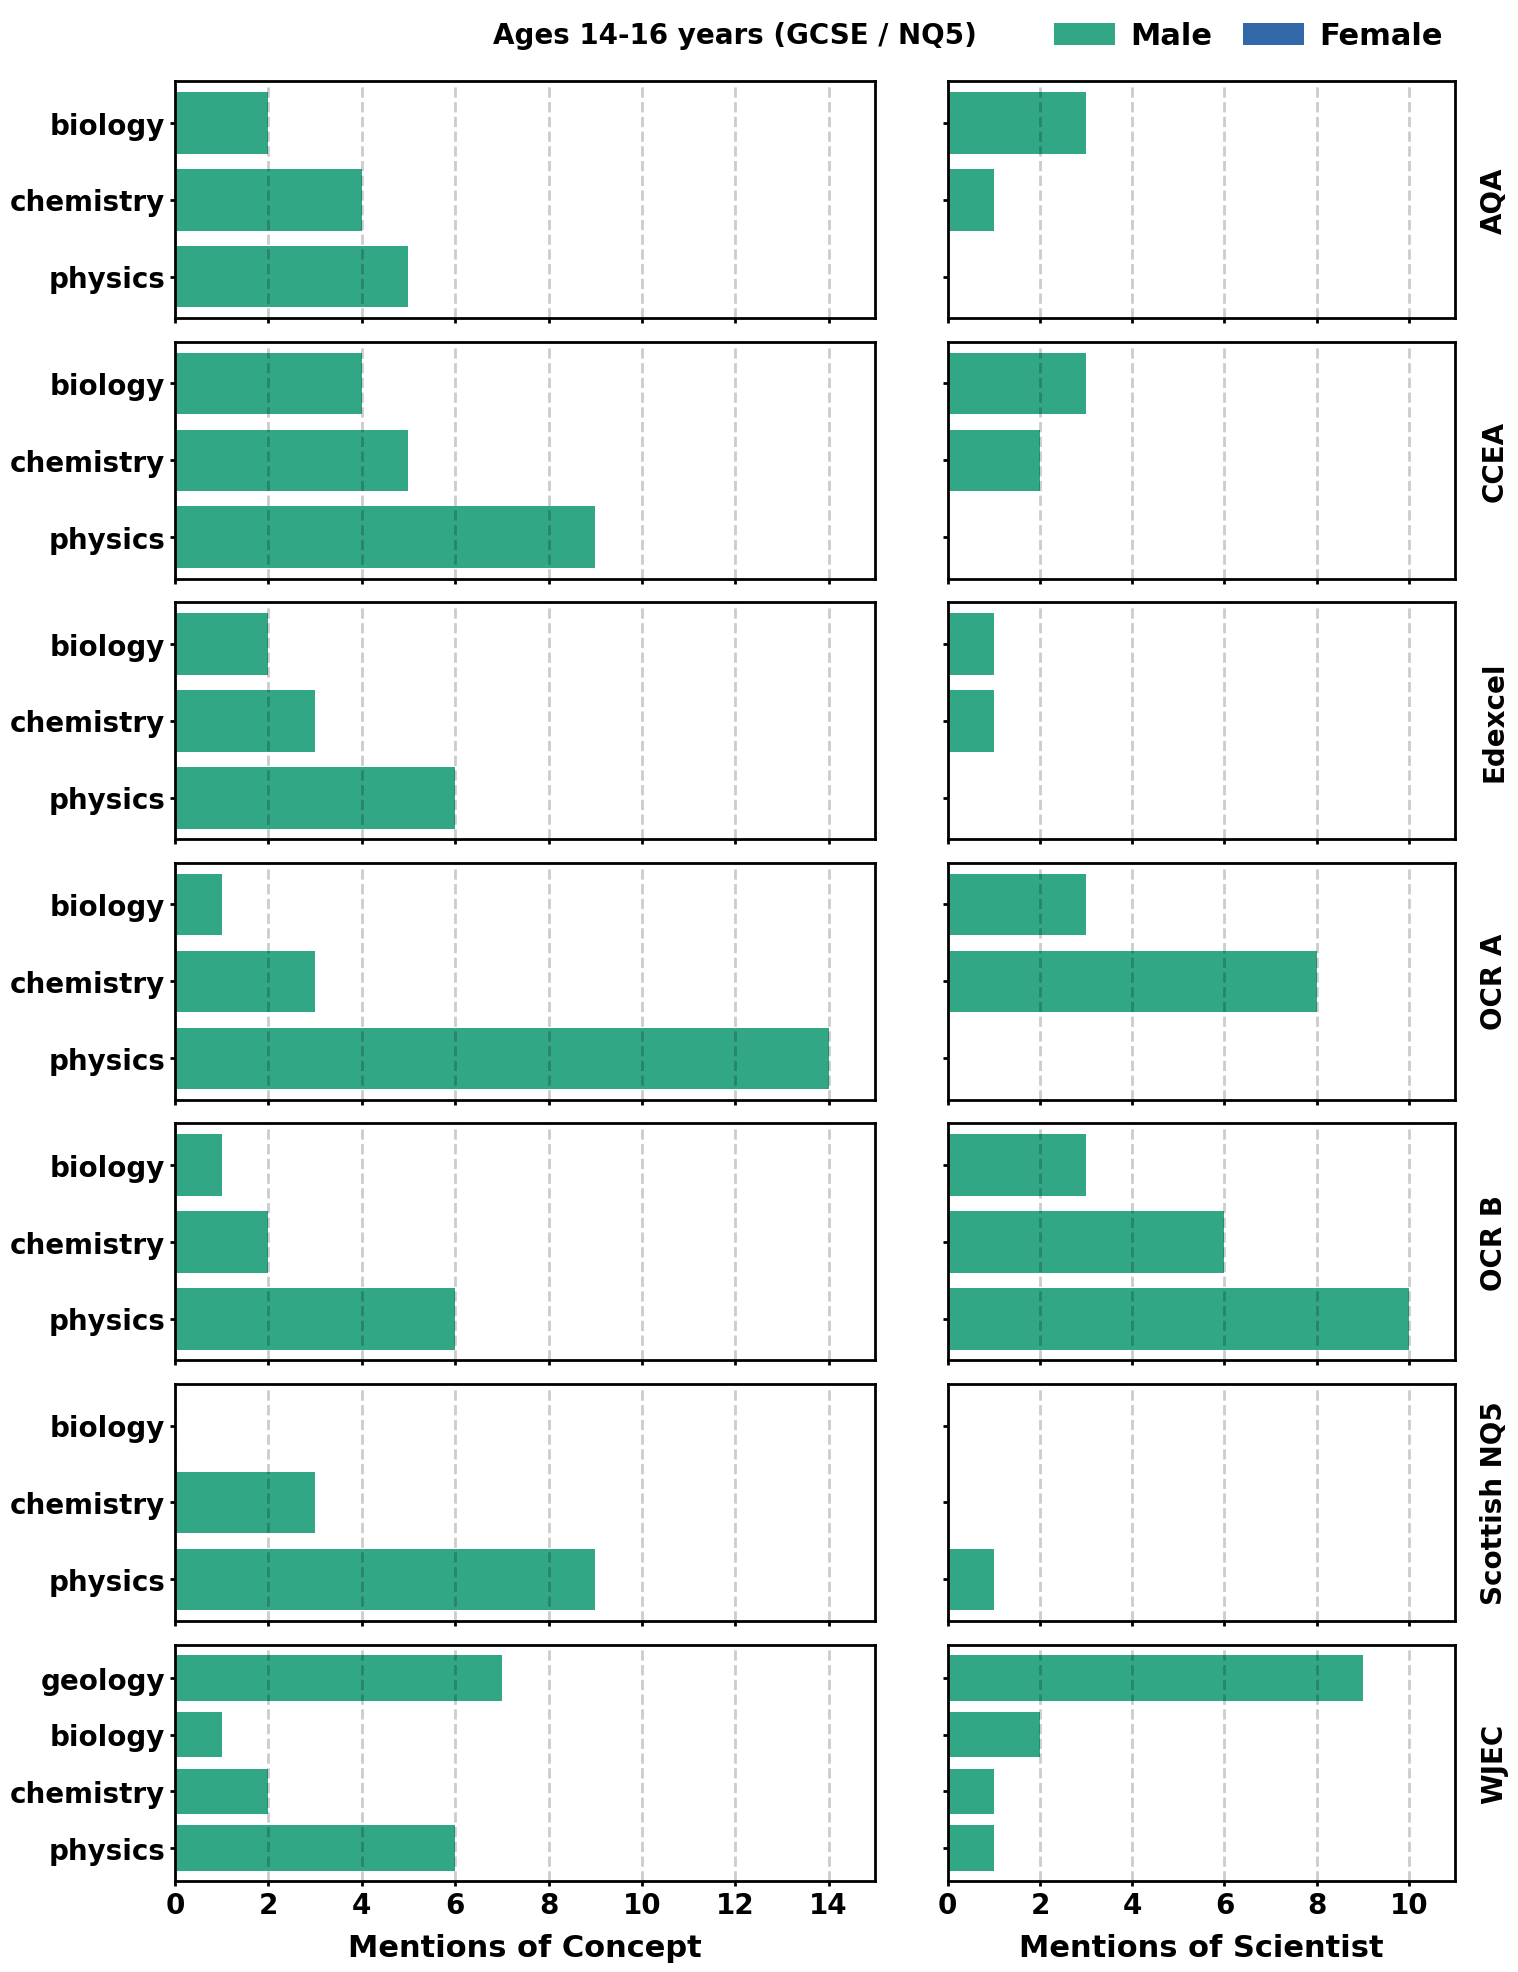

In [148]:
# ------------------------------------------------------------
# Create horizontal bar chart for breakdown across subjects
# ------------------------------------------------------------
core_subjects = {"physics", "chemistry", "biology"}

fig, axs = plt.subplots(
    nrows=len(exam_boards),
    ncols=2,
    figsize=(16, 20),
    gridspec_kw={'width_ratios': [0.58, 0.42]}
)

# ------------------------------------------------------------
# Left column: concepts
# ------------------------------------------------------------

for ii, board in enumerate(exam_boards):

    subjects_here = [
    sb for sb, data in dataset[EXAMBOARDS[board]]["subjects"].items()
    if (
        sb in core_subjects
        or (
            "concept" in data
            and (data["concept"]["male"] + data["concept"]["female"]) > 0
        )
    )
    ]
    
    y = range(len(subjects_here))

    male = []
    female = []

    for sb in subjects_here:
        cat = dataset[EXAMBOARDS[board]]["subjects"][sb].get("concept")
        if cat is None:
            m, f = 0, 0
        else:
            m, f = cat["male"], cat["female"]
        male.append(m)
        female.append(f)

    axs[ii, 0].barh(y, male, color=colours[1], alpha=0.9)
    axs[ii, 0].barh(y, female, left=male, color=colours[0], alpha=0.9)

    axs[ii, 0].set_yticks(y)
    axs[ii, 0].set_yticklabels(subjects_here)

    axs[ii, 1].text(
        1.05,                          # slightly outside the right side
        0.5,                           # vertically centered
        'Scottish NQ5' if board == 'Scottish NQ5' else board,
        rotation=90,                   # rotate text vertically
        ha='left',                      # left-align text
        va='center',                    # vertically centered
        fontsize=20,                    # adjust font size
        fontweight='bold',            # regular weight
        transform=axs[ii, 1].transAxes
    )

    axs[ii, 0].set_xlim(0, 15)

    if ii != len(exam_boards) - 1:
        axs[ii, 0].tick_params(labelbottom=False)


# ------------------------------------------------------------
# Right column: scientists
# ------------------------------------------------------------

for ii, board in enumerate(exam_boards):

    subjects_here = [
    sb for sb, data in dataset[EXAMBOARDS[board]]["subjects"].items()
    if (
        sb in core_subjects
        or (
            "concept" in data
            and (data["concept"]["male"] + data["concept"]["female"]) > 0
        )
    )
    ]

    y = range(len(subjects_here))

    male = []
    female = []

    for sb in subjects_here:
        cat = dataset[EXAMBOARDS[board]]["subjects"][sb].get("scientist")
        if cat is None:
            m, f = 0, 0
        else:
            m, f = cat["male"], cat["female"]
        male.append(m)
        female.append(f)

    axs[ii, 1].barh(y, male, color=colours[1], alpha=0.9)
    axs[ii, 1].barh(y, female, left=male, color=colours[0], alpha=0.9)

    axs[ii, 1].set_yticks(y)
    axs[ii, 1].set_yticklabels(subjects_here)

    axs[ii, 1].set_xlim(0, 11)
    axs[ii, 1].tick_params(labelleft=False)

    if ii != len(exam_boards) - 1:
        axs[ii, 1].tick_params(labelbottom=False)


# ------------------------------------------------------------
# Axis labels, legend, layout
# ------------------------------------------------------------

axs[-1, 0].set_xlabel("Mentions of Concept", labelpad=10)
axs[-1, 1].set_xlabel("Mentions of Scientist", labelpad=10)

plt.figlegend(
    ['Male', 'Female'],
    bbox_to_anchor=(0.95, 0.986),
    bbox_transform=fig.transFigure,
    ncol=2,
    borderaxespad=0.,
    handletextpad=0.5,
    columnspacing=1
)

plt.subplots_adjust(
    wspace=0.12,
    hspace=0.1,
    left=0.15,
    right=0.95,
    top=0.95,
    bottom=0.05
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20, weight = 'bold')

# ------------------------------------------------------------
# Vertical grid only (x-axis), no horizontal grid
# ------------------------------------------------------------
for ax in axs.flat:
    ax.grid(True, axis='x', linewidth=2)
    ax.grid(False, axis='y')
    
plt.savefig(
    '../Figures/summary_subjects_GCSE_UK.png',
    dpi=100,
    bbox_inches='tight'
)
print(dataset["WJEC_GCSE"]["subjects"].keys())


### Male compared to female mentions

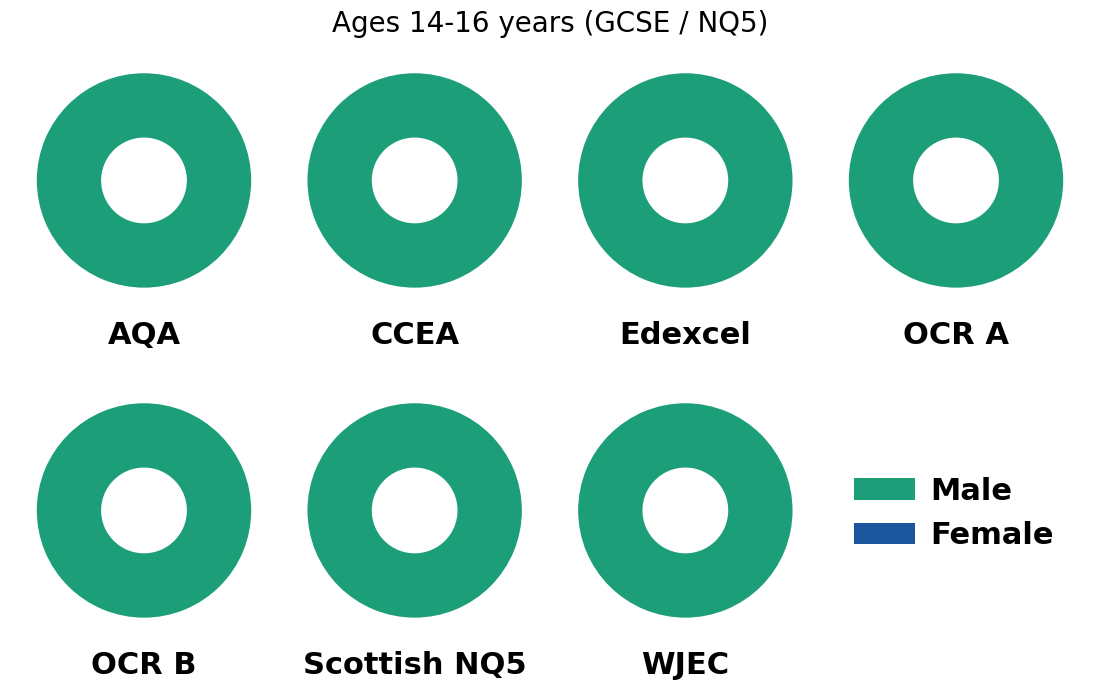

In [149]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 7))
ax = ax.flatten()

# One pie per exam board
for jj, board in enumerate(exam_boards):
    board_key = EXAMBOARDS[board]

    m = dataset[board_key]["overall"]["unique"]["male"]
    f = dataset[board_key]["overall"]["unique"]["female"]
    val = [m, f]

    if f == 0:
        ax[jj].pie(
            val,
            colors=[colours[1], colours[0]],
            startangle=80,
            wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val,
            colors=[colours[1], colours[0]],
            startangle=80,
            wedgeprops=dict(width=.6),
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 16, 'color': 'white'}
        )

    # Axis label
    if board == 'Scottish_highers':
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(board)

# Hide unused axes
for kk in range(len(exam_boards), len(ax)):
    ax[kk].axis('off')


plt.figlegend(
    ['Male', 'Female'],
    bbox_to_anchor=(0.93, 0.33),
    bbox_transform=fig.transFigure,
    ncol=1,
    borderaxespad=0.,
    handletextpad=0.5,
    columnspacing=1
)

# Layout
plt.subplots_adjust(
    wspace=0.01,
    hspace=0.1,
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20)

plt.savefig(
    '../Figures/summary_male_vs_female_UK_GCSE.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()


### Exam boards

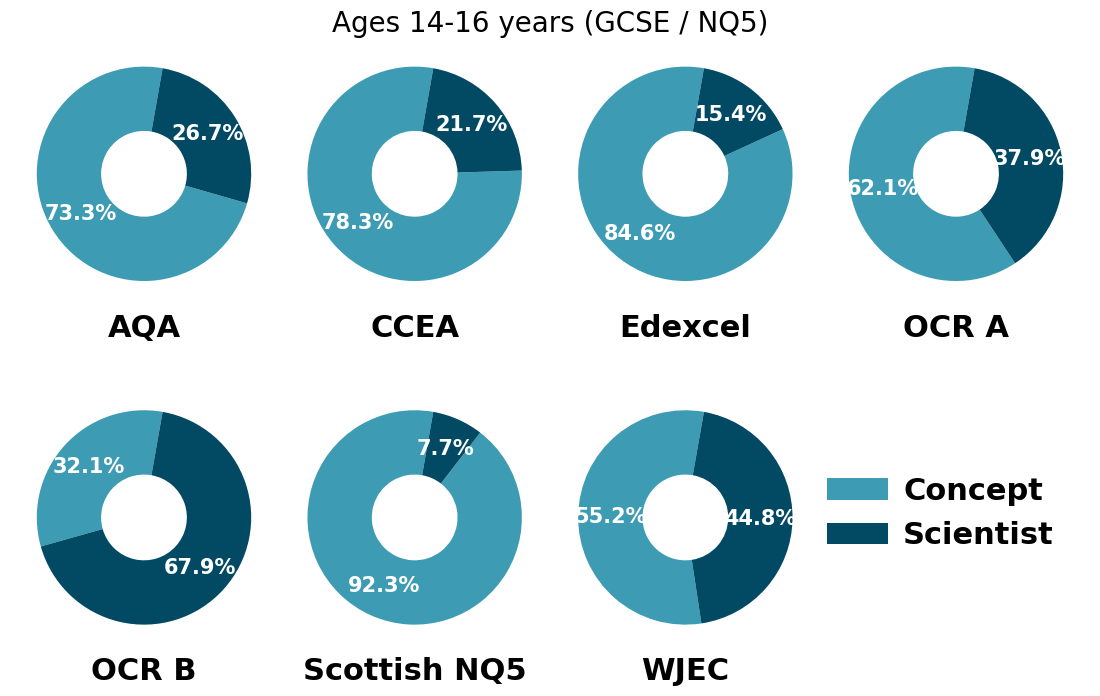

In [150]:
# Create pie charts showing scientist vs concept breakdown per exam board
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12, 7))
ax = ax.flatten()  # Flatten to simplify iteration

# Plot one pie per exam board
for jj, board in enumerate(exam_boards):
    board_key = EXAMBOARDS[board]

    m1 = dataset[board_key]["overall"]["concept"]["male"]
    f1 = dataset[board_key]["overall"]["concept"]["female"]
    m2 = dataset[board_key]["overall"]["scientist"]["male"]
    f2 = dataset[board_key]["overall"]["scientist"]["female"]

    val = [m1 + f1, m2 + f2]  # [concepts, scientists]

    if m2 + f2 == 0:
        ax[jj].pie(
            val,
            colors=[colours[3], colours[2]],
            startangle=80,
            wedgeprops=dict(width=.6)
        )
    else:
        ax[jj].pie(
            val,
            colors=[colours[3], colours[2]],
            startangle=80,
            wedgeprops=dict(width=.6),
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 15, 'color': 'white'}
        )

    # Axis label
    if board == 'Scottish_highers':
        ax[jj].set_xlabel('Scottish Highers')
    else:
        ax[jj].set_xlabel(board)

# Hide unused axes (only the 8th subplot)
for kk in range(len(exam_boards), len(ax)):
    ax[kk].axis('off')

# Legend
plt.figlegend(
    ['Concept', 'Scientist'],
    bbox_to_anchor=(0.93, 0.33),
    bbox_transform=fig.transFigure,
    ncol=1,
    borderaxespad=0.,
    handletextpad=0.5,
    columnspacing=1
)

# Layout adjustments
plt.subplots_adjust(
    wspace=0.01,
    hspace=0.2,
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20)

plt.savefig(
    '../Figures/summary_concept_vs_scientist_UK_GCSE.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()


### Regions of the world

Excluded 'nan' or malformed region entries from 'overall':
  - 'nan'
Excluded 'nan' or malformed region entries from scientists:
  - 'nan'


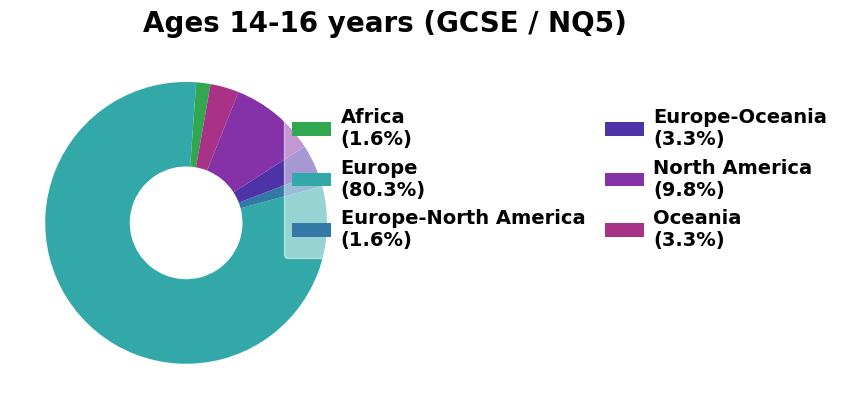

In [151]:
import matplotlib.pyplot as plt
import numpy as np

regions_G, vals_G, labels_G = collect_region_data(
    exam_boards, dataset, EXAMBOARDS
)

# --- Collect and clean data ---
region_list = []
nan_regions = set()
for state in exam_boards:
    region_keys = dataset[EXAMBOARDS[state]]["overall"]["unique"]["region"].keys()
    for r in region_keys:
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions.add(r)
            else:
                region_list.append(r_clean)
        else:
            nan_regions.add(r)

# Print nan or malformed entries
if nan_regions:
    print("Excluded 'nan' or malformed region entries from 'overall':")
    for r in nan_regions:
        print(f"  - {repr(r)}")

regions = sorted(set(region_list))

# Assign colors using a qualitative palette
cmap = plt.get_cmap('Set3')

Colours = ["#32a84e", "#32a8a8", "#3279a8",
           "#4e32a8", "#8532a8", "#a83285"]



#colours = [cmap(i % cmap.N) for i in range(len(regions))]

# --- Build list of unique scientist names and regions ---
name_list = []
region = []
nan_regions_scientist = set()
for state in exam_boards:
    names = list(dataset[EXAMBOARDS[state]]["names"].keys())
    for name in names:
        r = dataset[EXAMBOARDS[state]]["names"][name]["region"]
        if isinstance(r, str):
            r_clean = r.strip().title()
            if r_clean == "Eruope":
                r_clean = "Europe"
            if r_clean.lower() == "nan":
                nan_regions_scientist.add(r)
            else:
                region.append(r_clean)
                name_list.append(name)
        else:
            nan_regions_scientist.add(r)

# Print nan or malformed entries
if nan_regions_scientist:
    print("Excluded 'nan' or malformed region entries from scientists:")
    for r in nan_regions_scientist:
        print(f"  - {repr(r)}")

# Remove duplicate scientist names (preserve first mention)
idx = [name_list.index(x) for x in set(name_list)]
unique_names = [name_list[i] for i in idx]
region_names = [region[i] for i in idx]

# Count by region
vals = [region_names.count(rr) for rr in regions]

# Format region names with percentages for the legend
total = sum(vals)
region_labels = [f"{r} ({v/total*100:.1f}%)" for r, v in zip(regions, vals)]

def wrap_label(label, max_words=2):
    words = label.split()
    lines = []
    for i in range(0, len(words), max_words):
        lines.append(" ".join(words[i:i+max_words]))
    return "\n".join(lines)

region_labels = [
    f"{wrap_label(r)}\n({v/total*100:.1f}%)" for r, v in zip(regions, vals)
]


# --- Plotting ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

# Main pie chart (no % inside)
ax[0].pie(
    vals, colors=Colours, startangle=80,
    wedgeprops=dict(width=.6), textprops={'fontsize': 18, 'color': 'black'}
)

# Dummy pie chart for layout spacing
ax[1].pie(vals, colors=['white'] * len(vals))

# Legend with region names and percentages
plt.figlegend(
    region_labels,
    bbox_to_anchor=(0.95, 0.7),
    bbox_transform=fig.transFigure,
    ncol=2, borderaxespad=0., handletextpad=0.5, columnspacing=1,
    fontsize=14
)

plt.suptitle('Ages 14-16 years (GCSE / NQ5)', fontsize=20, y = 0.85, weight = 'bold')


plt.savefig('../Figures/summary_region_all_UK_GCSE.png',
            dpi=100,
            bbox_inches='tight')


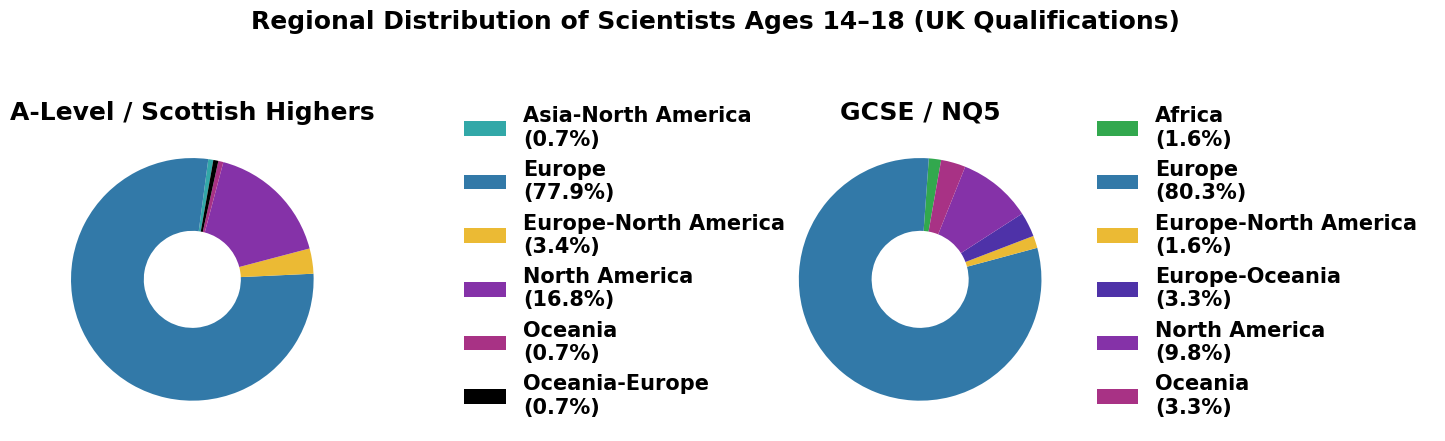

In [159]:

# ------------------------------------------------------------
# Colours (fixed qualitative palette)
# ------------------------------------------------------------
Colours = ["#32a84e", "#32a8a8", "#3279a8", '#ebba34',
           "#4e32a8", "#8532a8", "#a83285", "k"]

# Optional safety: enforce consistent region → colour mapping

all_regions = sorted(set(regions_A) | set(regions_G))
region_colour_map = dict(zip(all_regions, Colours))
colours_A = [region_colour_map[r] for r in regions_A]
colours_G = [region_colour_map[r] for r in regions_G]

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(18, 7))

# --- A-Level pie ---
wedges_A, _ = ax[0].pie(
    vals_A,
    colors=colours_A,
    startangle=80,
    wedgeprops=dict(width=0.6),
    textprops={'fontsize': 16}
)
ax[1].pie(vals_A, colors=['white'] * len(vals_A))

ax[0].set_title("A-Level / Scottish Highers", fontsize=18, weight="bold")

# --- GCSE pie ---
wedges_G, _ = ax[2].pie(
    vals_G,
    colors=colours_G,
    startangle=80,
    wedgeprops=dict(width=0.6),
    textprops={'fontsize': 16}
)
ax[3].pie(vals_G, colors=['white'] * len(vals_G))

ax[2].set_title("GCSE / NQ5", fontsize=18, weight="bold")

# ------------------------------------------------------------
# Legends (colour-correct)
# ------------------------------------------------------------
fig.legend(
    wedges_A,
    labels_A,
    loc="center left",
    bbox_to_anchor=(0.35, 0.52),
    fontsize=15
)

fig.legend(
    wedges_G,
    labels_G,
    loc="center right",
    bbox_to_anchor=(0.9, 0.52),
    fontsize=15
)

# ------------------------------------------------------------
# Figure title and save
# ------------------------------------------------------------
fig.suptitle(
    "Regional Distribution of Scientists Ages 14–18 (UK Qualifications)",
    fontsize=18,
    weight="bold",
    y=0.88
)

plt.savefig(
    "../Figures/summary_region_all_UK_combined.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()
